# P3 실습: 경사하강법

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**코드 실행**

[(구글 코랩) P3 실습: 경사하강법](https://colab.research.google.com/github/codingalzi/code-workout-ml/blob/master/p3_lab_gradient_descent.ipynb)에서 코드를 실행할 수 있다.

**환경설정**

In [1]:
import sys
import sklearn
from packaging.version import Version

assert sys.version_info >= (3, 10)
assert Version(sklearn.__version__) >= Version("1.6.1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rc("font", size=12)
plt.rc("axes", labelsize=13, titlesize=13)
plt.rc("legend", fontsize=11)

## 1단계: 좋은 직선은 무엇인가

### P0의 삶의 만족도 데이터를 다시 사용한다

[머신러닝 소개](https://codingalzi.github.io/code-workout-ml/p0-theory-handson-intro/) 국가별 **1인당 GDP**를 이용하여 **삶의 만족도**를 예측했다.

이번에도 같은 데이터를 사용한다.
이전과 마찬가지로 1인당 GDP가 23,500달러에서 62,500달러 사이인 31개 국가를 선택한다.

In [2]:
data_root = "https://github.com/codingalzi/code-workout-ml/raw/master/notebooks/datasets/"

lifesat_full = pd.read_csv(data_root + "lifesat/lifesat_full.csv")

lifesat_full.set_index("Country", inplace=True)

gdppc_col = "GDP per capita (USD)"
lifesat_col = "Life satisfaction"

min_gdp = 23_500
max_gdp = 62_500

lifesat = lifesat_full[
    (lifesat_full[gdppc_col] >= min_gdp)
    & (lifesat_full[gdppc_col] <= max_gdp)
]

print("선택된 국가 수:", len(lifesat))

선택된 국가 수: 31


P0에서는 GDP를 달러 단위 그대로 사용했다. 이번에는 경사하강법의 움직임을 쉽게 보기 위해 **1만 달러 단위**로 바꾸어 사용한다.

예를 들어 40,000달러는 `4.0`으로 표현된다.

단위만 바뀌었을 뿐 데이터의 관계는 그대로다.

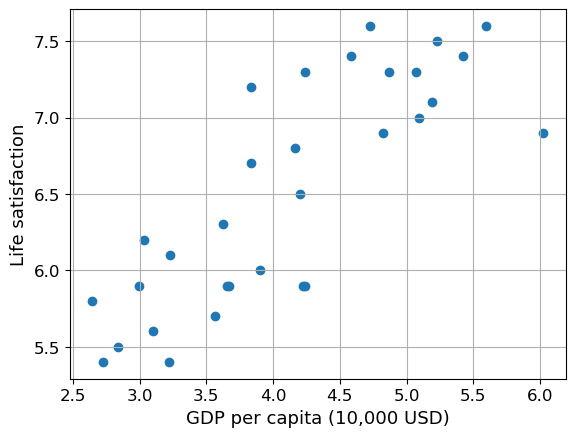

In [3]:
x = (lifesat[gdppc_col] / 10_000).to_numpy()
y = lifesat[lifesat_col].to_numpy()

plt.scatter(x, y)

plt.xlabel("GDP per capita (10,000 USD)")
plt.ylabel("Life satisfaction")
plt.grid()
plt.show()

### 직선은 두 개의 파라미터로 정해진다

하나의 특성을 사용하는 선형 회귀 모델은 다음 직선을 사용한다.

$$
\hat y = \theta_0 + \theta_1 x
$$

- $\theta_0$: 절편
- $\theta_1$: 기울기
- $x$: 1인당 GDP
- $\hat y$: 예측한 삶의 만족도

P0에서도 서로 다른 절편과 기울기를 가진 직선들을 비교했다. 같은 세 직선을 다시 확인한다.

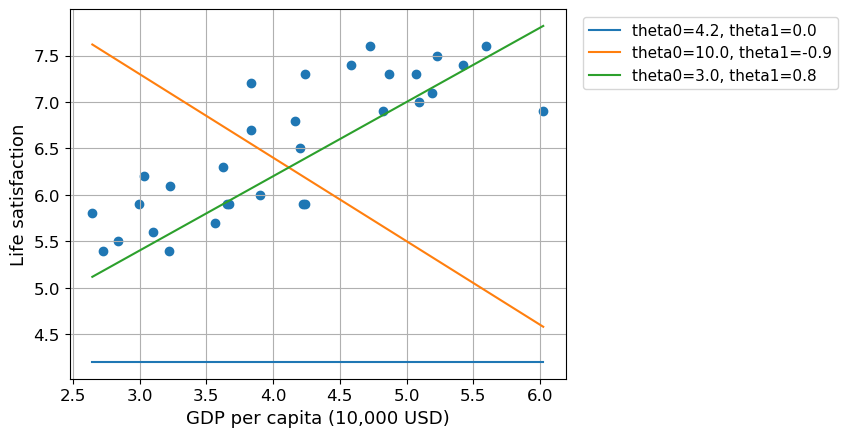

In [4]:
candidate_models = [
    {"theta_0": 4.2, "theta_1": 0.0},
    {"theta_0": 10.0, "theta_1": -0.9},
    {"theta_0": 3.0, "theta_1": 0.8},
]

x_line = np.linspace(x.min(), x.max(), 200)

plt.scatter(x, y)

for model in candidate_models:
    y_line = (model["theta_0"] + model["theta_1"] * x_line)

    plt.plot(x_line, 
             y_line, 
             label=(f"theta0={model['theta_0']}, "f"theta1={model['theta_1']}"))

plt.xlabel("GDP per capita (10,000 USD)")
plt.ylabel("Life satisfaction")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.grid()
plt.show()

직선이 달라지면 예측값도 달라진다. 그러면 어떤 직선이 더 좋은지 숫자로 비교할 기준이 필요하다.

회귀에서는 **평균 제곱 오차**(MSE)를 사용할 수 있다.

$$
\mathrm{MSE} = \frac{1}{m} \sum_{i=1}^{m} (\hat y^{(i)} - y^{(i)})^2
$$

여기서는 공식을 외우기보다 다음 의미만 기억한다.

> **예측값과 실제값의 차이가 클수록 MSE가 커지고, 잘 맞을수록 MSE가 작아진다.**

In [5]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

rows = []

for model in candidate_models:
    y_pred = (model["theta_0"] + model["theta_1"] * x)

    rows.append({
        "theta_0": model["theta_0"],
        "theta_1": model["theta_1"],
        "MSE": mse(y, y_pred)
    })

pd.DataFrame(rows)

,theta_0,theta_1,MSE
0,4.2,0.0,5.887097
1,10.0,-0.9,2.196645
2,3.0,0.8,0.243992


### 1단계 확인

세 직선의 MSE를 비교한다.

- MSE가 가장 작은 직선은 어느 것인가?
- 그래프에서 데이터에 가장 잘 맞아 보였던 직선과 일치하는가?
- 더 좋은 절편과 기울기가 있을 수 있을까?

모델 훈련의 목표는 바로 **MSE를 더 작게 만드는 파라미터를 찾는 것**이다.

## 2단계: 경사하강법은 어떻게 좋은 직선을 찾는가

### 한 번에 정답을 맞히는 것이 아니라 조금씩 수정한다

경사하강법은 처음부터 최적의 $\theta_0$, $\theta_1$을 알고 시작하지 않는다.

먼저 임의의 값에서 시작한 다음 다음 과정을 반복한다.

> **현재 파라미터 → 예측 → MSE 확인 → MSE가 줄어드는 방향 확인 → 파라미터 조금 수정**

이 한 번의 수정을 **스텝**(step)이라고 생각할 수 있다.

파라미터를 수정하는 핵심 형태는 다음과 같다.

$$
\text{새 파라미터} = \text{현재 파라미터} - \text{학습률} \times \text{기울기}
$$

여기서 **기울기**(gradient)는 현재 위치에서 파라미터를 어느 방향으로 바꾸면 MSE가 증가하는지를 알려준다.

따라서 그 **반대 방향**으로 움직이면 MSE를 줄일 수 있다.

이번 실습에서는 기울기의 계산식을 직접 유도하지 않는다. 아래 코드에 주어진 계산식을 사용하여 **파라미터가 어떻게 움직이고 MSE가 어떻게 감소하는지**를 관찰한다.

### 경사하강법을 직접 실행한다

경사하강법을 시작하려면 파라미터의 초기값이 필요하다. 초기값은 0이나 임의의 값으로 정할 수 있다. 이번 선형 회귀 예제에서는 학습 과정을 쉽게 관찰하기 위해
$\theta_0 = \theta_1=0$에서 시작한다.

그리고 모든 31개 국가를 이용해 MSE와 기울기를 계산한 다음, 파라미터를 한 번씩 수정한다.

In [6]:
def run_gradient_descent(x, y, learning_rate=0.01, epochs=100):
    theta_0 = 0.0
    theta_1 = 0.0

    history = []

    for epoch in range(epochs + 1):
        y_pred = theta_0 + theta_1 * x
        error = y_pred - y

        current_mse = np.mean(error ** 2)

        history.append({
            "epoch": epoch,
            "theta_0": theta_0,
            "theta_1": theta_1,
            "MSE": current_mse
        })

        if epoch == epochs:
            break

        # MSE를 줄이기 위한 기울기
        gradient_0 = 2 * np.mean(error)
        gradient_1 = 2 * np.mean(error * x)

        # 기울기의 반대 방향으로 조금 이동
        theta_0 = (theta_0 - learning_rate * gradient_0)
        theta_1 = (theta_1 - learning_rate * gradient_1)

    return pd.DataFrame(history)

In [7]:
history = run_gradient_descent(x, y, learning_rate=0.01, epochs=100)

history.head(10)

,epoch,theta_0,theta_1,MSE
0,0,0.000000,0.000000,42.982581
1,1,0.130323,0.546907,17.286374
2,2,0.213032,0.888928,7.220559
3,3,0.265942,1.102719,3.277174
4,4,0.300200,1.236256,1.731949
5,5,0.322784,1.319566,1.126084
6,6,0.338061,1.371441,0.888168
7,7,0.348763,1.403643,0.794379
8,8,0.356601,1.423531,0.757046
9,9,0.362646,1.435714,0.741827


표를 보면 에포크가 진행될수록 $\theta_0$와 $\theta_1$이 조금씩 바뀐다.

이번에는 시작과 마지막을 비교한다.

In [8]:
history.iloc[[0, 1, 5, 20, 100]]

,epoch,theta_0,theta_1,MSE
0,0,0.000000,0.000000,42.982581
1,1,0.130323,0.546907,17.286374
5,5,0.322784,1.319566,1.126084
20,20,0.400992,1.449401,0.721997
100,100,0.634213,1.395338,0.650356


### 직선이 어떻게 움직이는지 본다

경사하강법이 진행되는 동안 몇 개의 시점에서 직선을 그려 본다.

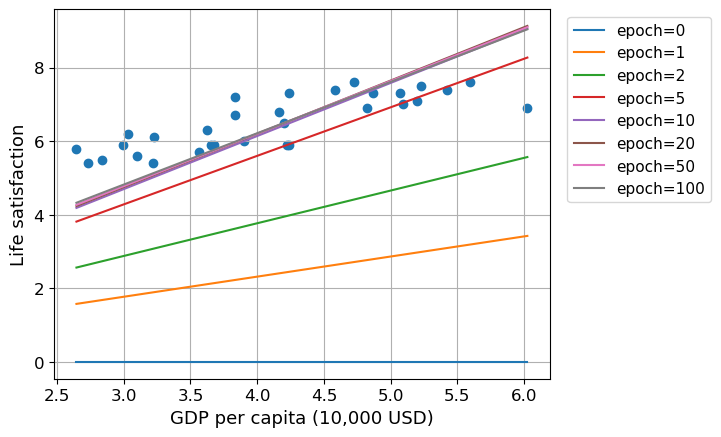

In [9]:
check_epochs = [0, 1, 2, 5, 10, 20, 50, 100]

plt.scatter(x, y)

x_line = np.linspace(x.min(), x.max(), 200)

for epoch in check_epochs:
    row = history.loc[history["epoch"] == epoch].iloc[0]

    y_line = (row["theta_0"] + row["theta_1"] * x_line)

    plt.plot(x_line, y_line, label=f"epoch={epoch}")

plt.xlabel("GDP per capita (10,000 USD)")
plt.ylabel("Life satisfaction")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid()
plt.show()

처음의 직선은 데이터와 거의 맞지 않는다. 하지만 파라미터를 반복해서 수정하면서 직선이 데이터의 전체적인 방향에 가까워진다.

이것이 `fit()` 내부에서 일어나는 **모델 훈련의 핵심 아이디어**다.

### MSE도 함께 확인한다

좋은 방향으로 학습되고 있다면 에포크가 진행될수록 MSE가 감소해야 한다.

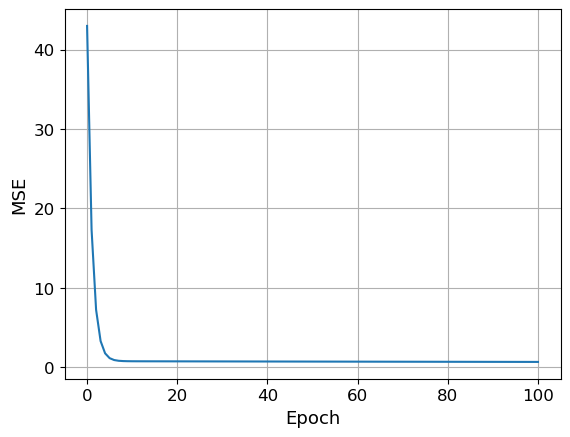

In [10]:
plt.plot(history["epoch"], history["MSE"])

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

### `LinearRegression`이 찾은 결과와 비교한다

P0에서는 `LinearRegression.fit()`을 이용해 절편과 기울기를 자동으로 학습했다.

같은 데이터를 사용하여 결과를 비교한다.

In [11]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(x.reshape(-1, 1), y)

gd_final = history.iloc[-1]

comparison = pd.DataFrame({
    "Gradient Descent": [
        gd_final["theta_0"],
        gd_final["theta_1"],
        gd_final["MSE"]
    ],
    "LinearRegression": [
        linear_reg.intercept_,
        linear_reg.coef_[0],
        mse(y, linear_reg.predict(x.reshape(-1, 1)))
    ]
}, index=["theta_0", "theta_1", "MSE"])

comparison

,Gradient Descent,LinearRegression
theta_0,0.634213,3.839382
theta_1,1.395338,0.650545
MSE,0.650356,0.175290


두 방법이 완전히 같은 방식으로 파라미터를 구하는 것은 아니다. 하지만 충분히 학습한 경사하강법은 `LinearRegression`이 찾은 좋은 직선에 가까워진다.

핵심은 다음이다.

> **`fit()`은 결국 데이터에 잘 맞는 파라미터를 찾는 과정이고, 경사하강법은 그 파라미터를 반복적인 수정으로 찾아가는 방법이다.**

### 학습률이 중요한 이유

**학습률**(learning rate)은 한 스텝에서 얼마나 크게 움직일지를 정한다.

같은 데이터, 같은 모델, 같은 초기값을 사용하고 **학습률만 바꾸어** 비교한다.

학습률이 0.01일 때 MSE가 가장 빠르게 최저점으로 수렴한다.

반면에 0.0001로 너무 작으면 MSE가 훨씬 느리게 수렴하는 것으로 보인다.

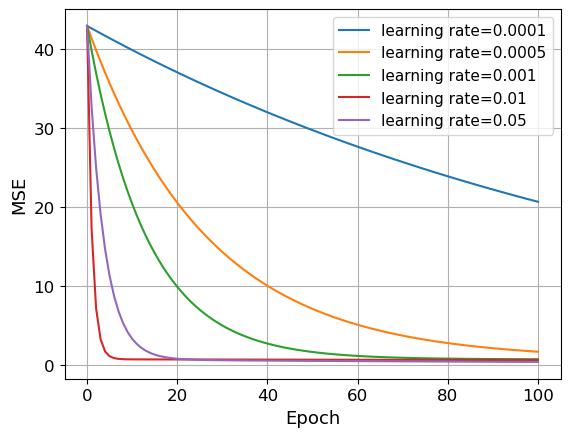

In [15]:
learning_rates = [0.0001, 0.0005, 0.001, 0.01, 0.05]

histories = {}

for rate in learning_rates:
    histories[rate] = run_gradient_descent(x, y, learning_rate=rate, epochs=100)

for rate, hist in histories.items():
    plt.plot(hist["epoch"], hist["MSE"], label=f"learning rate={rate}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

반면에 학습률이 0.054 이상이면 MSE가 수렴하지 않고 오히려 폭발적으로 증가, 즉 발산한다.

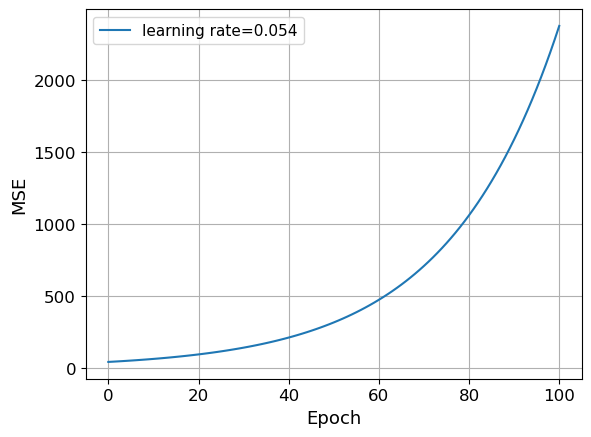

In [13]:
learning_rates = [0.054]

histories = {}

for rate in learning_rates:
    histories[rate] = run_gradient_descent(x, y, learning_rate=rate, epochs=100)

for rate, hist in histories.items():
    plt.plot(hist["epoch"], hist["MSE"], label=f"learning rate={rate}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
# plt.yscale("log")

plt.legend()
plt.grid()
plt.show()

그래프를 보면서 다음을 확인한다.

- **학습률이 너무 작으면** 파라미터가 조금씩만 움직여 학습이 느리다.
- **적절한 학습률이면** MSE가 빠르게 감소한다.
- **학습률이 너무 크면** MSE가 불안정하게 움직이거나 아예 발산할 수 있다.

좋은 학습률은 데이터와 모델에 따라 달라질 수 있다.

### 배치 → 스텝 → 에포크 → 학습률

지금까지 사용한 예제로 네 용어를 연결하면 다음과 같다.

**배치(batch)**  
한 번의 파라미터 업데이트에 사용하는 데이터 묶음이다. 지금까지는 31개 국가 **전체**를 한 번에 사용했다.

**스텝(step)**  
한 배치로 예측하고 MSE를 계산한 뒤 $\theta_0$, $\theta_1$을 한 번 업데이트하는 과정이다.

**에포크(epoch)**  
훈련 데이터 전체를 한 번 사용한 과정이다. 지금 예제에서는 한 배치가 전체 31개 국가이므로 **한 스텝이 곧 한 에포크**다.

**학습률(learning rate)**  
각 스텝에서 파라미터를 얼마나 크게 움직일지를 정한다.

지금까지 사용한 방식처럼 **훈련 데이터 전체를 한 배치로 사용하는 경사하강법**을 배치 경사하강법이라고 한다.

### 2단계 확인

다음을 자신의 말로 설명할 수 있는지 확인한다.

- 모델의 파라미터는 무엇인가?
- MSE가 작다는 것은 무엇을 의미하는가?
- 경사하강법은 왜 기울기의 반대 방향으로 움직이는가?
- 학습률이 하는 역할은 무엇인가?
- 지금 실습에서 한 스텝과 한 에포크가 같은 이유는 무엇인가?

## 실습 정리

이번 실습에서 기억할 핵심은 다음과 같다.

- 선형 회귀의 훈련은 데이터에 잘 맞는 **절편과 가중치**를 찾는 과정이다.
- 모델의 예측 오차는 MSE와 같은 손실 함수로 측정할 수 있다.
- 경사하강법은 손실을 줄이는 방향으로 파라미터를 조금씩 수정한다.
- 학습률은 한 번에 얼마나 크게 수정할지를 결정한다.
- 이번 실습에서는 훈련셋 전체를 한 번에 사용했으며, 이를 **배치 경사하강법**이라고 한다.
- 한 배치가 전체 훈련셋이므로 이번 예제에서는 **한 스텝이 곧 한 에포크**다.

> **모델 훈련 = 예측 → 오차 확인 → 파라미터 수정 → 반복**